In [29]:
# Product Experimentation & User Engagement Analytics

## Business Problem

An online fashion retailer wants to improve customer engagement by redesigning the product pages.

Before investing in expensive A/B tests, the analytics team wants to identify which design elements are most strongly associated with user engagement.

This project analyzes historical clickstream data to recommend future product experiments.

---

## Business Questions

1. Which product presentation leads to higher engagement?
2. Does product position affect browsing behaviour?
3. Does product photography influence user interaction?
4. Which product categories receive the most attention?
5. Which experiment should the company prioritize?

---

## Tools

- Python
- Pandas
- SQL
- Power BI
- Statistical Analysis


SyntaxError: invalid syntax (3659211038.py, line 5)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [31]:
file_path = "../data/raw/e-shop clothing 2008.csv"

df = pd.read_csv(file_path, sep=";")

print(df.shape)

(165474, 14)


In [32]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

In [34]:
df.describe(include="all")

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
count,165474.0,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B4,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3579,NaN,NaN,NaN,NaN,NaN,NaN
mean,2008.0,5.585887,14.524554,9.817476,26.952621,12058.417056,2.400842,NaN,6.227655,3.258198,1.260071,43.802507,1.488167,1.710166
std,0.0,1.328160,8.830374,13.478411,7.150691,7008.418903,1.144420,NaN,4.235606,1.713206,0.438674,12.548131,0.499861,0.982412
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5931.000000,1.000000,NaN,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11967.500000,2.000000,NaN,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18219.000000,3.000000,NaN,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000


In [35]:
df.nunique()

year                           1
month                          5
day                           31
order                        195
country                       47
session ID                 24026
page 1 (main category)         4
page 2 (clothing model)      217
colour                        14
location                       6
model photography              2
price                         20
price 2                        2
page                           5
dtype: int64

In [36]:
df.isnull().sum()


year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64

In [10]:
165474 / 24026

6.8872887704986265

In [37]:
session_clicks = (
    df.groupby("session ID")
      .size()
      .rename("clicks")
)

session_clicks.describe()

count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
Name: clicks, dtype: float64

In [13]:
df.duplicated().sum()

0

In [8]:
category_counts = (
    df["page 1 (main category)"]
      .value_counts()
      .sort_index()
)

category_counts

1    49742
2    38408
3    38577
4    38747
Name: page 1 (main category), dtype: int64

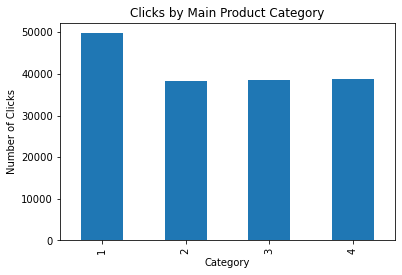

In [9]:
import matplotlib.pyplot as plt

category_counts.plot(kind="bar")

plt.title("Clicks by Main Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Clicks")

plt.show()

In [10]:
category_percent = (
    df["page 1 (main category)"]
      .value_counts(normalize=True)
      .sort_index() * 100
)

category_percent.round(2)

1    30.06
2    23.21
3    23.31
4    23.42
Name: page 1 (main category), dtype: float64

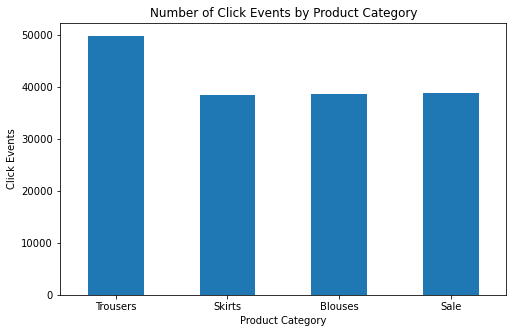

In [11]:
category_names = {
    1: "Trousers",
    2: "Skirts",
    3: "Blouses",
    4: "Sale"
}

category_counts.index = category_counts.index.map(category_names)

category_counts.plot(kind="bar", figsize=(8,5))

plt.title("Number of Click Events by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Click Events")

plt.xticks(rotation=0)
plt.show()

In [12]:
### data cleaning
df["page 1 (main category)"].value_counts().sort_index()

1    49742
2    38408
3    38577
4    38747
Name: page 1 (main category), dtype: int64

In [39]:
dfclean = df.rename(columns={
    "session ID": "session_id",
    "page 1 (main category)": "main_category",
    "page 2 (clothing model)": "product_id",
    "model photography": "photo_type",
    "price 2": "price_category",
    "page": "page_number"
})

In [40]:
dfclean.columns

Index(['year', 'month', 'day', 'order', 'country', 'session_id',
       'main_category', 'product_id', 'colour', 'location', 'photo_type',
       'price', 'price_category', 'page_number'],
      dtype='object')

In [41]:
category_labels = {
    1: "Trousers",
    2: "Skirts",
    3: "Blouses",
    4: "Sale"
}

In [43]:
dfclean["main_category_name"] = dfclean["main_category"].map(category_labels)

In [45]:
photo_labels = {
    1: "Front View",
    2: "Profile View"
}

dfclean["photo_type_name"] = dfclean["photo_type"].map(photo_labels)

In [46]:
location_labels = {
    1: "Top Left",
    2: "Top Middle",
    3: "Top Right",
    4: "Bottom Left",
    5: "Bottom Middle",
    6: "Bottom Right"
}

dfclean["location_name"] = dfclean["location"].map(location_labels)

In [47]:
price_category_labels = {
    1: "Above Category Average",
    2: "Below Category Average"
}

dfclean["price_category_name"] = dfclean["price_category"].map(price_category_labels)

In [49]:
colour_labels = {
    1: "Beige",
    2: "Black",
    3: "Blue",
    4: "Brown",
    5: "Burgundy",
    6: "Gray",
    7: "Green",
    8: "Navy Blue",
    9: "Red",
    10: "Violet",
    11: "White",
    12: "Orange",
    13: "Pink",
    14: "Unknown"
}

dfclean["colour_name"] = dfclean["colour"].map(colour_labels)

In [50]:
dfclean.head()

,year,month,day,order,country,session_id,main_category,product_id,colour,location,photo_type,price,price_category,page_number,main_category_name,photo_type_name,location_name,price_category_name,colour_name
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1,Trousers,Front View,Bottom Middle,Below Category Average,Beige
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1,Trousers,Front View,Bottom Right,Below Category Average,Beige
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1,Skirts,Front View,Top Middle,Above Category Average,Violet
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1,Skirts,Profile View,Bottom Right,Below Category Average,Gray
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1,Skirts,Profile View,Top Right,Above Category Average,Brown


In [51]:
dfclean.to_csv("../data/processed/clickstream_clean.csv", index=False)

In [27]:
df_clean = pd.read_csv("../data/processed/clickstream_clean.csv")

print(df_clean.shape)
df_clean.head()

(165474, 14)


,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1
